In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns
from scipy.signal import find_peaks
import os

# Загрузка данных
spectrum_df = pd.read_csv('spectrum_metrics.csv')

# Просмотр структуры данных
print("Размер данных:", spectrum_df.shape)
print("\nПервые 5 строк:")
print(spectrum_df.head())
print("\nИнформация о данных:")
print(spectrum_df.info())

Размер данных: (245, 15)

Первые 5 строк:
   Unnamed: 0    A         w   df  \
0           0  0.1  0.700004  0.1   
1           1  0.1  2.333348  0.1   
2           2  0.1  3.966692  0.1   
3           3  0.1  5.600035  0.1   
4           4  0.1  7.233379  0.1   

                                   results_file        f1        f2        f3  \
0  sim_304f2f88-8c71-46ef-9837-fab09f11aa1f.npz  1.119998  0.999998  0.779998   
1  sim_8c28fcb7-71e0-44bd-a617-6bf513a528ec.npz  1.119998  0.739999  1.499997   
2  sim_c7db4098-77c6-424b-aed5-2527fee688e4.npz  1.259997  0.639999  1.899996   
3  sim_f50de58e-906f-46a8-bc34-e039dc548522.npz  0.899998  1.779996  1.179998   
4  sim_da7e1164-1538-4ced-96dc-015e3ffd6875.npz  1.159998  2.299995  0.100000   

         f4        f5       Aq1       Aq2       Aq3       Aq4       Aq5  
0  0.559999  0.659999  0.057874  0.016165  0.012760  0.010309  0.009184  
1  0.379999  1.859996  0.172138  0.008370  0.005007  0.003823  0.002924  
2  3.159994  0.000000  0.0

In [29]:
# 1. Подготовка данных для кластеризации
# Используем частоты и амплитуды для кластеризации
features_for_clustering = ['f1', 'f2', 'f3', 'f4', 'f5', 'Aq1', 'Aq2', 'Aq3', 'Aq4', 'Aq5']

# Список полей для нормировки
norm_columns = ['Aq1', 'Aq2', 'Aq3', 'Aq4', 'Aq5']

# Удаляем строки с пропущенными значениями
clustering_data = spectrum_df[features_for_clustering].dropna()
clustering_data[norm_columns] = clustering_data[norm_columns].div(clustering_data['Aq1'], axis=0)
# Стандартизация данных
scaler = StandardScaler()
scaled_data = scaler.fit_transform(clustering_data)
print("\nПервые 5 строк:")
print(clustering_data.head())
print(f"Данных для кластеризации: {len(clustering_data)}")


Первые 5 строк:
         f1        f2        f3        f4        f5  Aq1       Aq2       Aq3  \
0  1.119998  0.999998  0.779998  0.559999  0.659999  1.0  0.279320  0.220471   
1  1.119998  0.739999  1.499997  0.379999  1.859996  1.0  0.048626  0.029085   
2  1.259997  0.639999  1.899996  3.159994  0.000000  1.0  0.271702  0.078645   
3  0.899998  1.779996  1.179998  1.219998  2.659995  1.0  0.252109  0.031014   
4  1.159998  2.299995  0.100000  0.000000  0.000000  1.0  0.013360  0.012765   

        Aq4       Aq5  
0  0.178130  0.158692  
1  0.022207  0.016989  
2  0.010306  0.000000  
3  0.028763  0.014399  
4  0.000000  0.000000  
Данных для кластеризации: 245


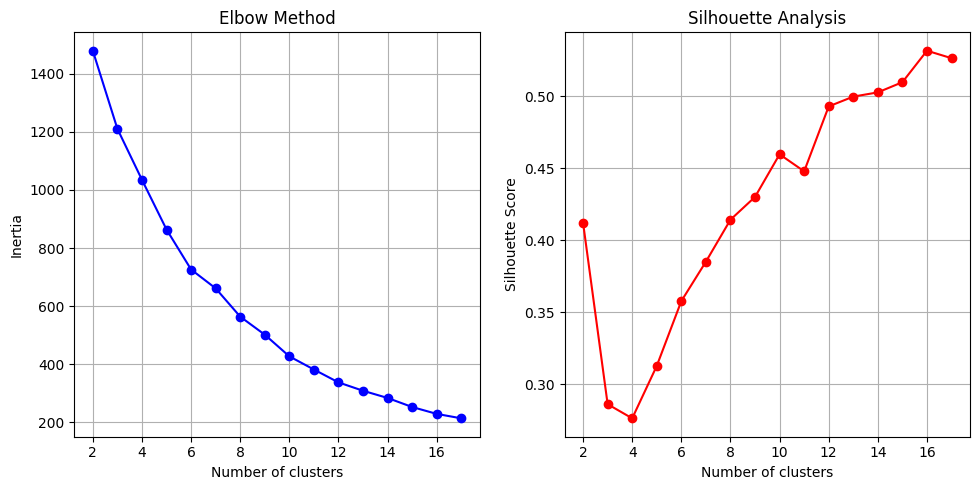

In [30]:
# 2. Определение оптимального числа кластеров
# Метод локтя и силуэтный анализ
inertia = []
silhouette_scores = []
k_range = range(2, 18)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)
    
    if k > 1:  # silhouette_score требует как минимум 2 кластера
        silhouette_scores.append(silhouette_score(scaled_data, kmeans.labels_))

# Визуализация метода локтя
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'ro-')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.grid(True)

plt.tight_layout()
plt.show()

In [55]:
# 3. Кластеризация K-means (выберем оптимальное k на основе графиков)
optimal_k = 10 # Можете изменить на основе графиков выше
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=15)
cluster_labels = kmeans.fit_predict(scaled_data)

# Добавляем метки кластеров в исходные данные
clustering_data = clustering_data.copy()
clustering_data['cluster'] = cluster_labels
print(clustering_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   f1       245 non-null    float64
 1   f2       245 non-null    float64
 2   f3       245 non-null    float64
 3   f4       245 non-null    float64
 4   f5       245 non-null    float64
 5   Aq1      245 non-null    float64
 6   Aq2      245 non-null    float64
 7   Aq3      245 non-null    float64
 8   Aq4      245 non-null    float64
 9   Aq5      245 non-null    float64
 10  cluster  245 non-null    int32  
dtypes: float64(10), int32(1)
memory usage: 20.2 KB
None


In [56]:
# 4. Анализ кластеров
print("\nРазмеры кластеров:")
print(clustering_data['cluster'].value_counts().sort_index())

# Средние значения по кластерам
cluster_means = clustering_data.groupby('cluster').mean()
print("\nСредние значения по кластерам:")
print(cluster_means)


Размеры кластеров:
cluster
0    26
1    36
2     9
3    28
4    32
5    11
6    10
7    68
8    16
9     9
Name: count, dtype: int64

Средние значения по кластерам:
               f1        f2        f3        f4        f5  Aq1       Aq2  \
cluster                                                                    
0        1.119998  0.579999  0.602306  0.605383  0.596922  1.0  0.404794   
1        1.578886  2.378884  2.504439  0.962220  0.539999  1.0  0.039451   
2        0.979998  0.359999  0.462221  0.877776  0.262222  1.0  0.847893   
3        1.239998  0.602856  1.688568  0.113571  0.000000  1.0  0.408143   
4        1.071248  1.023123  1.092498  1.034373  1.997496  1.0  0.239250   
5        1.352725  1.747269  1.339997  3.647265  0.645453  1.0  0.123882   
6        0.739999  1.119998  0.379999  1.479997  1.859996  1.0  0.706202   
7        1.178527  2.100584  0.033823  0.002647  0.000000  1.0  0.037005   
8        0.867498  1.874996  2.884994  0.018750  0.000000  1.0  0.158447  

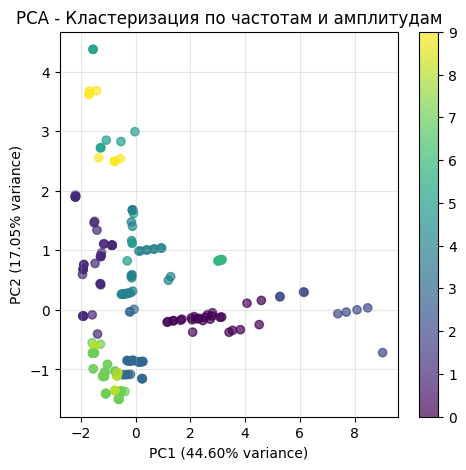

In [57]:
# 5. PCA для визуализации кластеров в пространстве признаков
pca_features = PCA(n_components=2)
pca_result_features = pca_features.fit_transform(scaled_data)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter = plt.scatter(pca_result_features[:, 0], pca_result_features[:, 1], 
                     c=cluster_labels, cmap='viridis', alpha=0.7)
plt.colorbar(scatter)
plt.xlabel(f'PC1 ({pca_features.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_features.explained_variance_ratio_[1]:.2%} variance)')
plt.title('PCA - Кластеризация по частотам и амплитудам')
plt.grid(True, alpha=0.3)

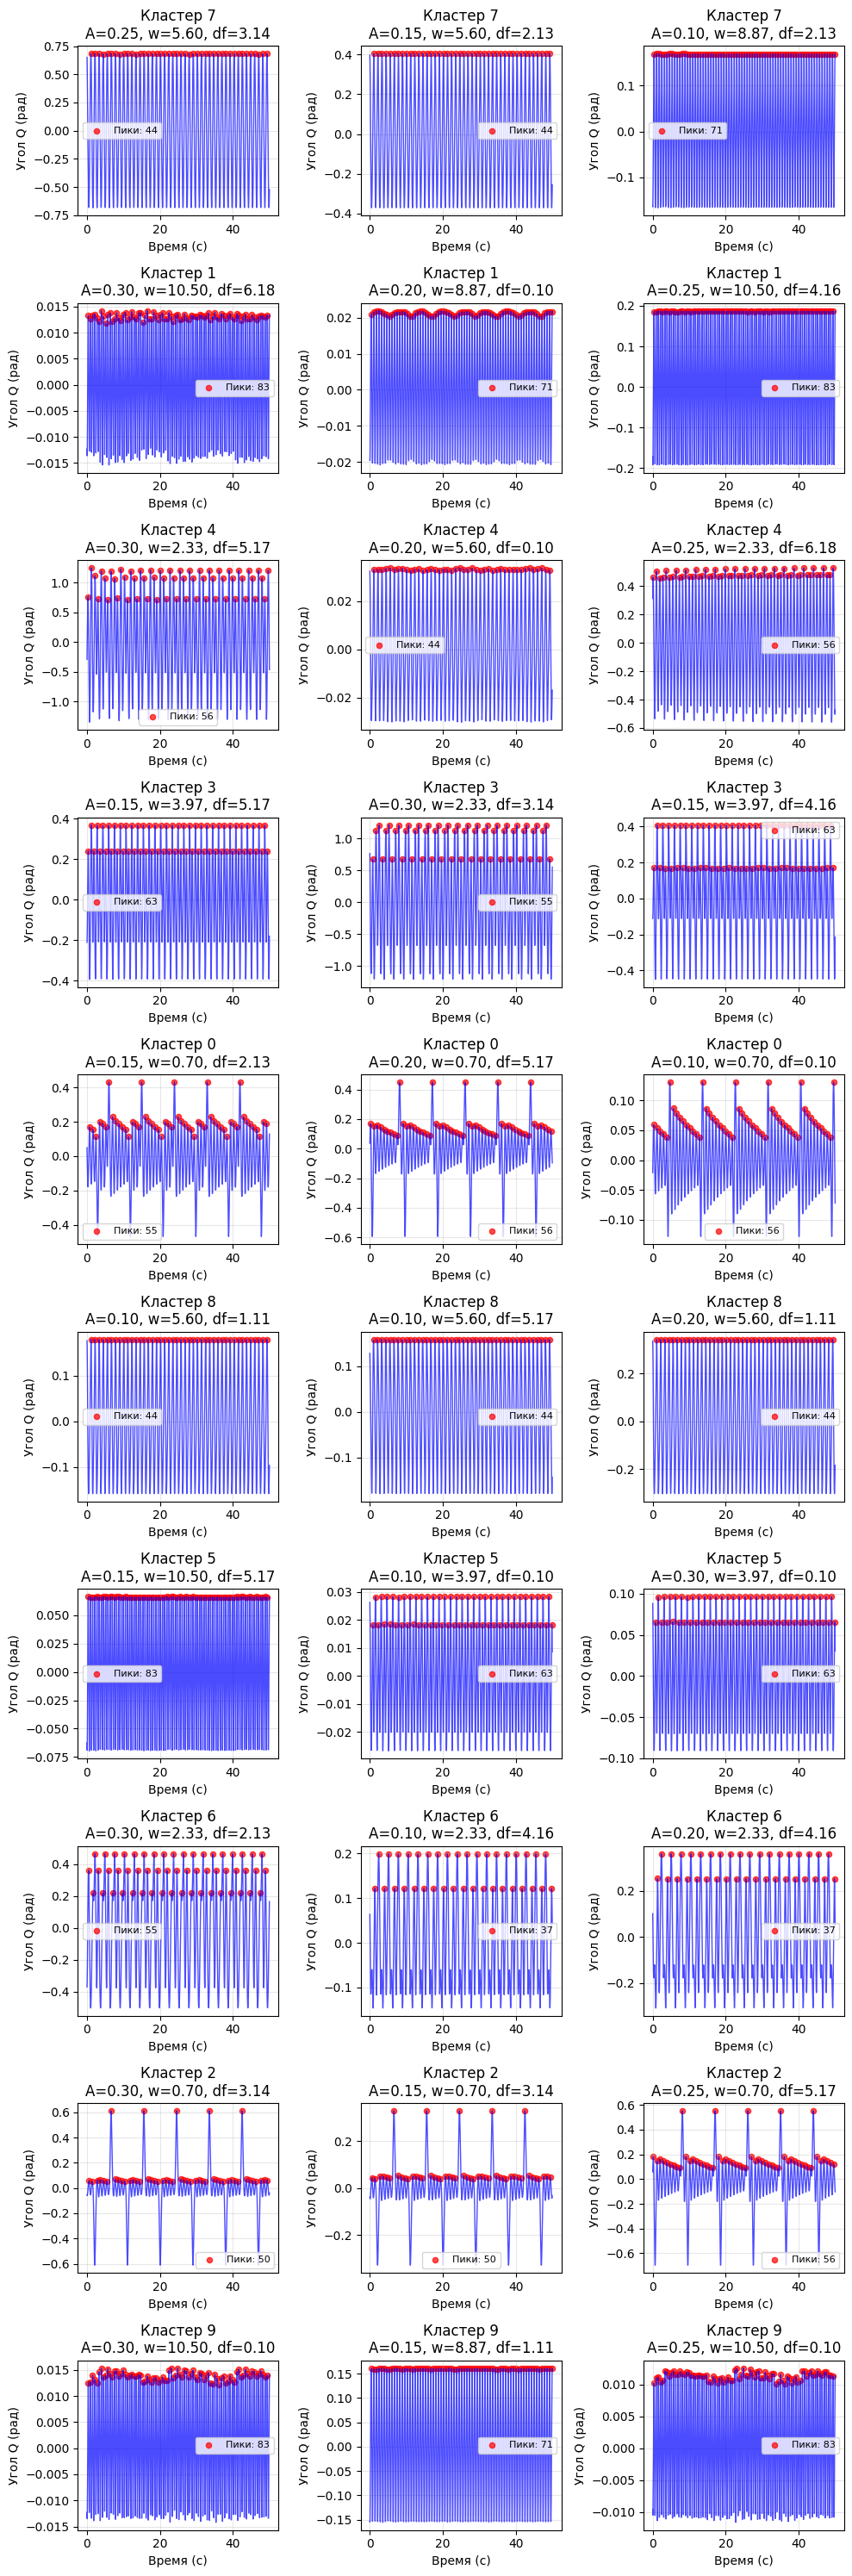

In [58]:
def plot_detailed_cluster_trajectories(spectrum_df, cluster_labels, results_dir="results", n_clusters_to_plot=3):
    """
    Детальная визуализация с дополнительной информацией о кластерах
    """
    
    spectrum_df_clustered = spectrum_df.copy()
    spectrum_df_clustered['cluster'] = cluster_labels
    
    # Выбираем наиболее представительные кластеры (с наибольшим количеством точек)
    cluster_counts = spectrum_df_clustered['cluster'].value_counts()
    clusters_to_plot = cluster_counts.head(n_clusters_to_plot).index
    
    fig = plt.figure(figsize=(10, 3 * n_clusters_to_plot))
    
    for i, cluster_id in enumerate(clusters_to_plot):
        cluster_data = spectrum_df_clustered[spectrum_df_clustered['cluster'] == cluster_id]
        
        # Выбираем 3 представителя из кластера
        representatives = cluster_data.sample(min(3, len(cluster_data)), random_state=42)
        
        for j, (_, row) in enumerate(representatives.iterrows()):
            try:
                # Создаем subplot для каждого представителя
                ax1 = plt.subplot(n_clusters_to_plot, 3, i * 3 + j + 1)
                
                # Загружаем данные
                data = np.load(os.path.join(results_dir, row['results_file']))
                Q = data['Q']
                T = data['T']
                
                # Применяем маску и коррекцию
                mask = T > 15 * 1000
                Q_masked = Q[mask] - np.pi/2
                T_masked = T[mask]
                T_normalized = (T_masked - T_masked[0]) / 1000
                
                # Траектория угла
                ax1.plot(T_normalized, Q_masked, 'b-', alpha=0.7, linewidth=1)
                ax1.set_title(f'Кластер {cluster_id}\nA={row["A"]:.2f}, w={row["w"]:.2f}, df={row["df"]:.2f}')
                ax1.set_xlabel('Время (с)')
                ax1.set_ylabel('Угол Q (рад)')
                ax1.grid(True, alpha=0.3)
                
                # Добавляем информацию о пиках
                peaks, _ = find_peaks(Q_masked, height=0)
                if len(peaks) > 0:
                    ax1.scatter(T_normalized[peaks], Q_masked[peaks], 
                              color='red', s=20, alpha=0.7, label=f'Пики: {len(peaks)}')
                    ax1.legend(fontsize=8)
                
            except Exception as e:
                print(f"Ошибка при загрузке файла {row['results_file']}: {e}")
                # Создаем пустой subplot с сообщением об ошибке
                ax1 = plt.subplot(n_clusters_to_plot, 3, i * 3 + j + 1)
                ax1.text(0.5, 0.5, f'Ошибка загрузки\n{e}', 
                        ha='center', va='center', transform=ax1.transAxes)
                ax1.set_title(f'Кластер {cluster_id} - Ошибка')
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Детальная версия
fig3 = plot_detailed_cluster_trajectories(spectrum_df, cluster_labels, 
                                        results_dir="results", 
                                        n_clusters_to_plot=optimal_k)

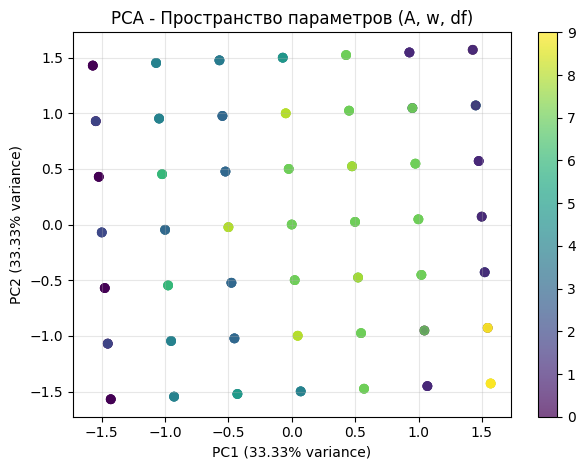

In [59]:
# 6. PCA в пространстве параметров (A, w, df)
params_for_pca = ['A', 'w', 'df']
params_data = spectrum_df[params_for_pca].values

# Стандартизация параметров
params_scaler = StandardScaler()
scaled_params = params_scaler.fit_transform(params_data)

# PCA для параметров
pca_params = PCA(n_components=2)
pca_result_params = pca_params.fit_transform(scaled_params)

# Используем цвета кластеров для соответствующих точек
valid_indices = clustering_data.index  # индексы данных, которые были использованы в кластеризации
scatter = plt.scatter(pca_result_params[valid_indices, 0], 
                     pca_result_params[valid_indices, 1], 
                     c=cluster_labels, cmap='viridis', alpha=0.7)
plt.colorbar(scatter)
plt.xlabel(f'PC1 ({pca_params.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_params.explained_variance_ratio_[1]:.2%} variance)')
plt.title('PCA - Пространство параметров (A, w, df)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

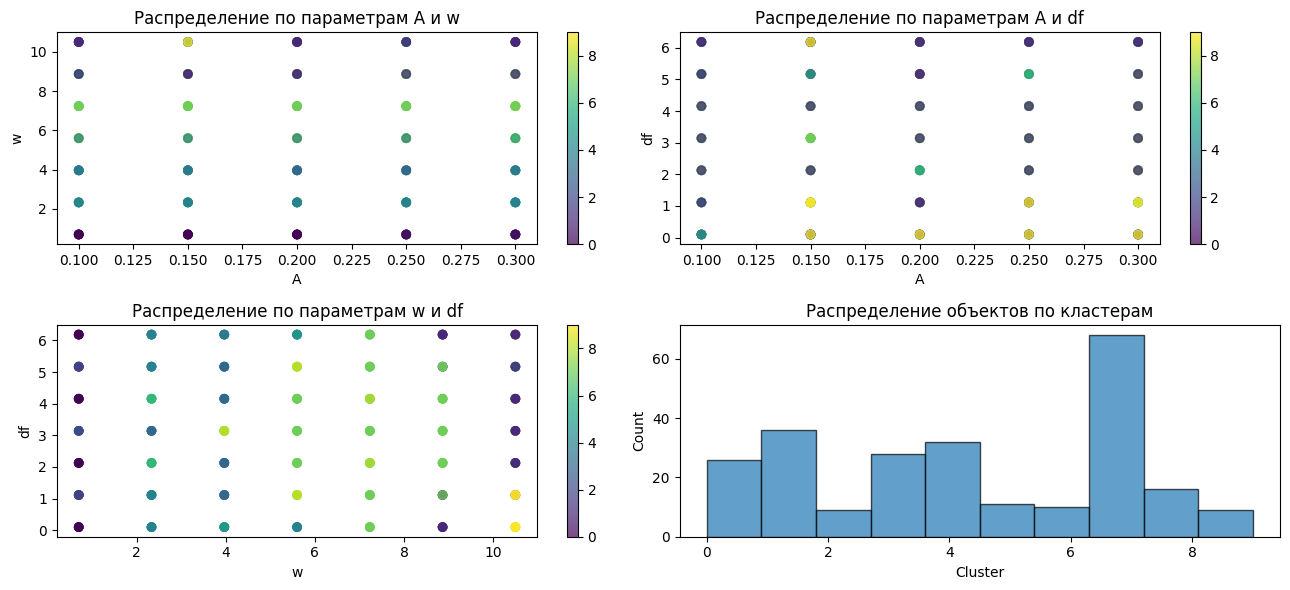

In [60]:
# 7. Дополнительная визуализация - распределение параметров по кластерам
fig, axes = plt.subplots(2, 2, figsize=(13, 6))

# A vs w с кластерами
scatter = axes[0, 0].scatter(spectrum_df.loc[valid_indices, 'A'], 
                            spectrum_df.loc[valid_indices, 'w'], 
                            c=cluster_labels, cmap='viridis', alpha=0.7)
axes[0, 0].set_xlabel('A')
axes[0, 0].set_ylabel('w')
axes[0, 0].set_title('Распределение по параметрам A и w')
plt.colorbar(scatter, ax=axes[0, 0])

# A vs df с кластерами
scatter = axes[0, 1].scatter(spectrum_df.loc[valid_indices, 'A'], 
                            spectrum_df.loc[valid_indices, 'df'], 
                            c=cluster_labels, cmap='viridis', alpha=0.7)
axes[0, 1].set_xlabel('A')
axes[0, 1].set_ylabel('df')
axes[0, 1].set_title('Распределение по параметрам A и df')
plt.colorbar(scatter, ax=axes[0, 1])

# w vs df с кластерами
scatter = axes[1, 0].scatter(spectrum_df.loc[valid_indices, 'w'], 
                            spectrum_df.loc[valid_indices, 'df'], 
                            c=cluster_labels, cmap='viridis', alpha=0.7)
axes[1, 0].set_xlabel('w')
axes[1, 0].set_ylabel('df')
axes[1, 0].set_title('Распределение по параметрам w и df')
plt.colorbar(scatter, ax=axes[1, 0])

# Гистограмма распределения по кластерам
axes[1, 1].hist(cluster_labels, bins=optimal_k, alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Распределение объектов по кластерам')

plt.tight_layout()
plt.show()